# Classifing with decision trees, random forests, pruning, interpretability, k-NN


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets._openml import fetch_openml

RNG = 42

## Decision Trees


### Task 1.

Load the _Adult Census Income_ dataset using $\texttt{fetch\_openml('adult',\ version=2)}$ and perform exploratory data analysis: column types, missing values, class distribution, splitting features into numerical and categorical, $P(\text{target}=1 \mid \text{feature})$ for categorical features.


#### Loading the dataset


In [4]:
dataset_name = "Adult Census Income"

try:
    ds = fetch_openml(name="adult", version=2, as_frame=True, parser="auto")
    df = ds.frame
    df["income"] = (df["class"] == ">50K").astype(int)
    df = df.drop(columns=["class"])
    target_col = "income"
    print(
        f"Dataset '{dataset_name}' loaded successfully: {df.shape[0]} samples, {df.shape[1]} features."
    )
    print(f"Class distribution:\n{df[target_col].value_counts()}")
    print(f"Baseline = {df[target_col].mean():.3f}")
except Exception as e:
    print(f"Error fetching dataset: {e}")
    df = None

Dataset 'Adult Census Income' loaded successfully: 48842 samples, 15 features.
Class distribution:
income
0    37155
1    11687
Name: count, dtype: int64
Baseline = 0.239


In [5]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


#### Column types and missing values


In [6]:
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isnull().sum(),
    "missing%": df.isnull().mean() * 100,
    "nunique": df.nunique(),
})
info

,dtype,missing,missing%,nunique
age,int64,0,0.000000,74
workclass,category,2799,5.730724,8
fnlwgt,int64,0,0.000000,28523
education,category,0,0.000000,16
education-num,int64,0,0.000000,16
marital-status,category,0,0.000000,7
occupation,category,2809,5.751198,14
relationship,category,0,0.000000,6
race,category,0,0.000000,5
sex,category,0,0.000000,2


In [7]:
num_cols = df.select_dtypes(include=["number"]).columns.drop(target_col).tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"({len(num_cols)}) Numerical columns: {num_cols}")
print(f"({len(cat_cols)}) Categorical columns: {cat_cols}")

(6) Numerical columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
(8) Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [8]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


#### Class distribution


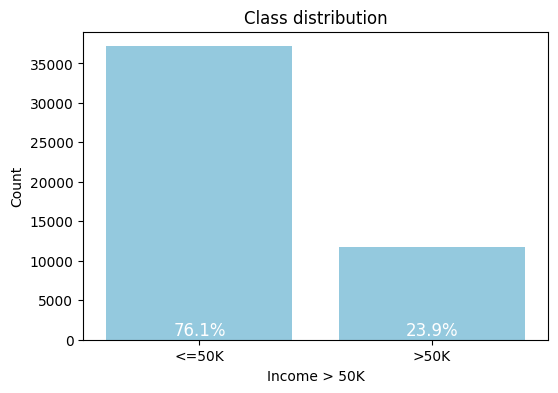

In [9]:
true_class = df[target_col] > 50_000
false_class = df[target_col] <= 50_000

total = len(df)

plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df, color="skyblue")
for i, count in enumerate(df[target_col].value_counts().sort_index()):
    plt.text(
        i,
        count / total * 100,
        f"{count / total * 100:.1f}%",
        ha="center",
        va="bottom",
        color="white",
        fontsize=12,
    )
plt.title("Class distribution")
plt.xlabel("Income > 50K")
plt.ylabel("Count")
plt.xticks([0, 1], ["<=50K", ">50K"])
plt.show()

#### P($\text{target}=1 \mid \text{feature}$) for categorical features


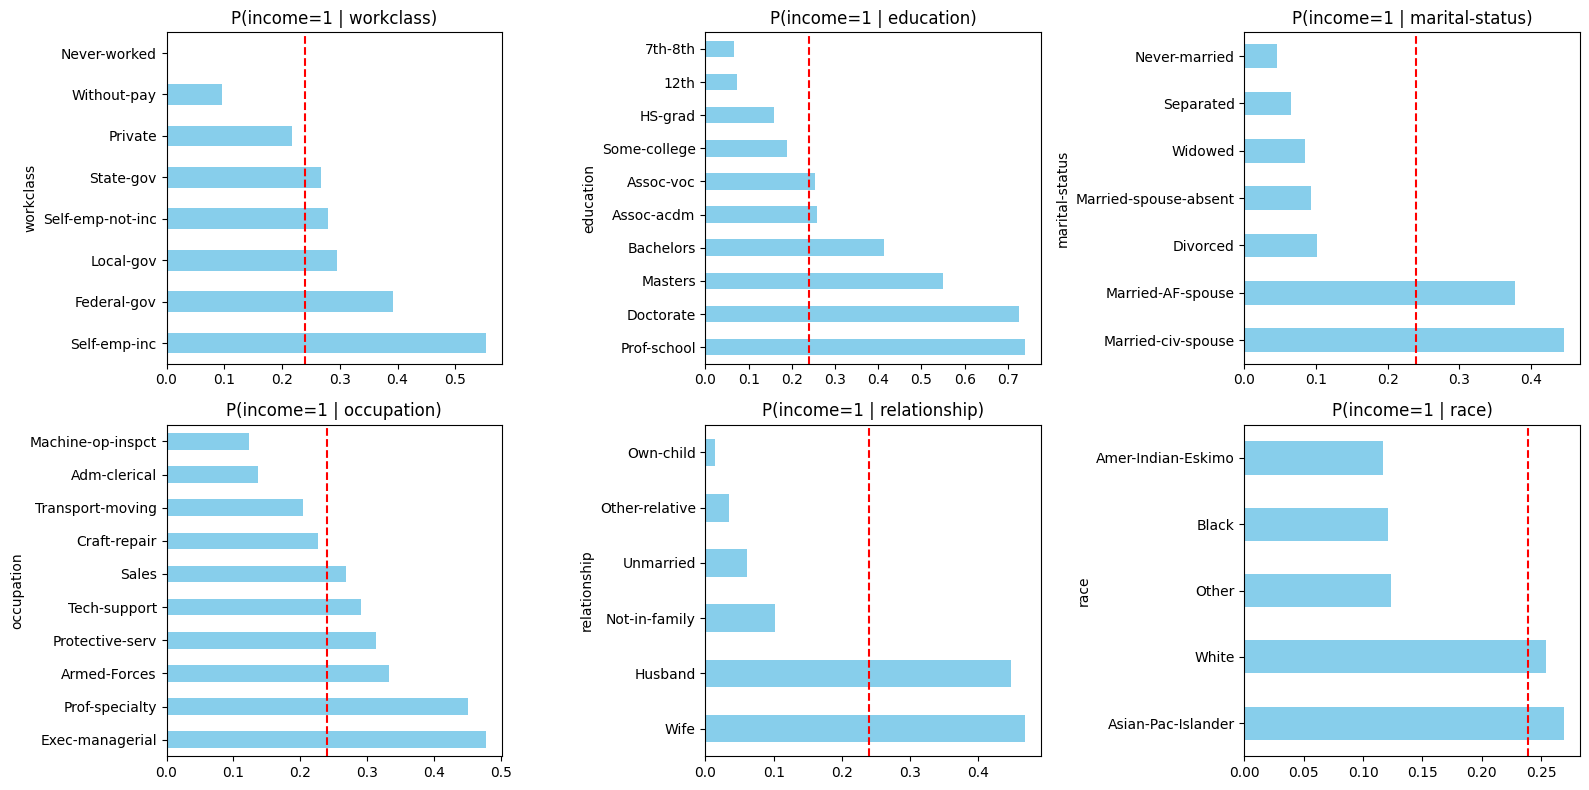

In [10]:
if cat_cols:
    fig, axes = plt.subplots(2, min(3, len(cat_cols)), figsize=(16, 8))
    axes = np.array(axes).ravel()
    for i, col in enumerate(cat_cols[:6]):
        vc = df.groupby(col)[target_col].mean().sort_values(ascending=False).head(10)
        vc.plot(
            kind="barh", ax=axes[i], title=f"{col} vs {target_col}", color="skyblue"
        )
        axes[i].axvline(
            df[target_col].mean(), color="red", linestyle="--", label="Baseline"
        )
        axes[i].set_title(f"P({target_col}=1 | {col})")
        axes[i].set_xlabel("")
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

### Task 2.

Build a preprocessing pipeline using $\texttt{ColumnTransformer}$, combining $\texttt{SimpleImputer}$ with $\texttt{OrdinalEncoder}$ for categorical features. Perform a stratified $75\%/25\%$ split.


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
    ),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

feature_names = num_cols + cat_cols
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# stratified split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RNG
)


print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"Class distribution in train: {y_train.value_counts(normalize=True)}")
print(f"Class distribution in test: {y_test.value_counts(normalize=True)}")

Training set: 36631 samples, 14 features
Test set: 12211 samples, 14 features
Class distribution in train: income
0    0.760722
1    0.239278
Name: proportion, dtype: float64
Class distribution in test: income
0    0.760708
1    0.239292
Name: proportion, dtype: float64


### Task 3.

Train a _full tree_ (without regularization) and observe overfitting: the difference between training and test accuracy. What depth was reached?


In [12]:
from sklearn.tree import DecisionTreeClassifier

base_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=RNG)),
])

base_pipeline.fit(X_train, y_train)
print("Full tree:")
print(f"\tdepth: {base_pipeline.named_steps['clf'].get_depth()}")
print(f"\tleaves: {base_pipeline.named_steps['clf'].get_n_leaves()}")
print(f"\tTrain accuracy: {base_pipeline.score(X_train, y_train):.4f}")
print(f"\tTest accuracy: {base_pipeline.score(X_test, y_test):.4f}")

Full tree:
	depth: 44
	leaves: 5450
	Train accuracy: 0.9999
	Test accuracy: 0.8178


> Depth = 44, strong overfitting.


### Task 4.

Using 10-fold cross-validation for $\texttt{max\_depth} \in \{1, \ldots, 20\}$, illustrate the bias-variance curve. Identify the optimal depth.


In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

depths = list(range(1, 21))
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RNG)
cv_scores = []

for d in depths:
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", DecisionTreeClassifier(max_depth=d, random_state=RNG)),
    ])
    s = cross_val_score(
        pipeline, X_train, y_train, cv=kf, scoring="balanced_accuracy", n_jobs=-1
    )
    cv_scores.append((s.mean(), s.std()))

In [14]:
best_depth = depths[np.argmax([s[0] for s in cv_scores])]
print(
    f"Best depth: {best_depth} with CV score: {max(cv_scores)[0]:.4f} ± {max(cv_scores)[1]:.4f}"
)

Best depth: 10 with CV score: 0.7785 ± 0.0117


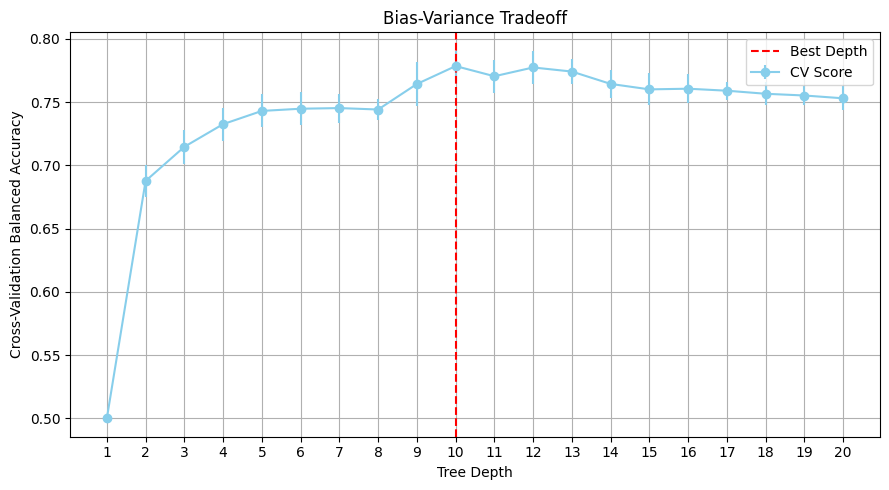

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    depths,
    [s[0] for s in cv_scores],
    yerr=[s[1] for s in cv_scores],
    marker="o",
    color="skyblue",
    label="CV Score",
)
ax.axvline(
    depths[np.argmax([s[0] for s in cv_scores])],
    color="red",
    linestyle="--",
    label="Best Depth",
)
ax.set_xlabel("Tree Depth")
ax.set_ylabel("Cross-Validation Balanced Accuracy")
ax.set_title("Bias-Variance Tradeoff")
ax.legend()
ax.set_xticks(depths)
plt.grid()
plt.tight_layout()
plt.show()

### Task 5.

For the full tree, call $\texttt{cost\_complexity\_pruning\_path()}$ to obtain the sequence $\alpha_0 < \alpha_1 < \ldots < \alpha_m$. For each $\alpha$:

- train a tree with $\texttt{ccp\_alpha}=\alpha$,
- record depth, number of leaves, train accuracy, test accuracy,
- visualize train/test accuracy and number of leaves as a function of $\alpha$.

Expected shape of the CCP curve: For $\alpha \rightarrow 0$ the tree is full (overfit); for $\alpha \rightarrow \alpha_{\max}$ the tree reduces to a root. We identify the optimum by CV.


In [16]:
cpp_alphas = base_pipeline.named_steps["clf"].cost_complexity_pruning_path(
    preprocessor.fit_transform(X_train), y_train
)
ccp_alphas, impurities = cpp_alphas.ccp_alphas, cpp_alphas.impurities
print(f"Number of effective alphas: {len(ccp_alphas)}")
print(f"Alphas: {ccp_alphas[:5]} ... {ccp_alphas[-5:]}")

Number of effective alphas: 1994
Alphas: [0.00000000e+00 9.09976068e-06 9.09976068e-06 1.31246548e-05
 1.32230897e-05] ... [0.01190093 0.01233601 0.02006751 0.02509139 0.05987019]


In [17]:
from joblib import Parallel, delayed
from tqdm import tqdm


def evaluate_alpha(alpha):
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", DecisionTreeClassifier(random_state=RNG, ccp_alpha=alpha)),
    ])
    pipeline.fit(X_train, y_train)
    return {
        "alpha": alpha,
        "depth": pipeline.named_steps["clf"].get_depth(),
        "leaf_count": pipeline.named_steps["clf"].get_n_leaves(),
        "train_acc": pipeline.score(X_train, y_train),
        "test_acc": pipeline.score(X_test, y_test),
    }


stats = Parallel(n_jobs=-1)(
    delayed(evaluate_alpha)(alpha) for alpha in tqdm(ccp_alphas)
)

100%|██████████| 1994/1994 [00:43<00:00, 45.98it/s]


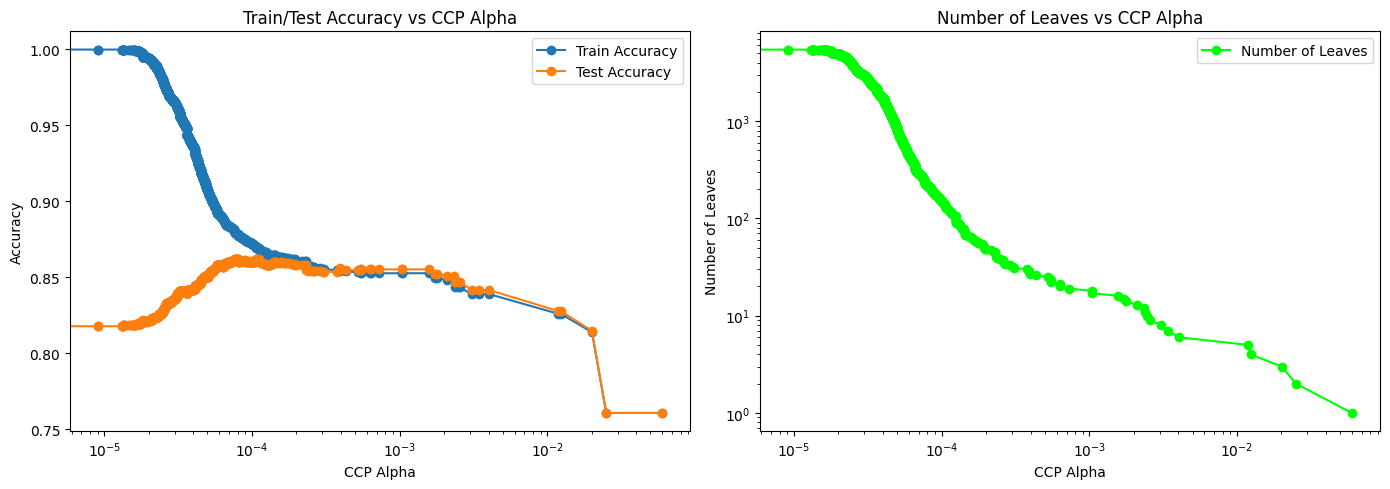

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(
    ccp_alphas, [s["train_acc"] for s in stats], label="Train Accuracy", marker="o"
)
axes[0].plot(
    ccp_alphas, [s["test_acc"] for s in stats], label="Test Accuracy", marker="o"
)
axes[0].set_xscale("log")
axes[0].set_xlabel("CCP Alpha")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Train/Test Accuracy vs CCP Alpha")
axes[0].legend()
axes[1].plot(
    ccp_alphas,
    [s["leaf_count"] for s in stats],
    label="Number of Leaves",
    marker="o",
    color="lime",
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("CCP Alpha")
axes[1].set_ylabel("Number of Leaves")
axes[1].set_title("Number of Leaves vs CCP Alpha")
axes[1].legend()
plt.tight_layout()
plt.show()

### Task 6.

Find the optimal $\alpha^*$ using $\texttt{GridSearchCV}$ with $\texttt{param\_grid=\{'ccp\_alpha':\ alphas\}}$ on 10-fold cross-validation.


In [19]:
from sklearn.model_selection import GridSearchCV

parameters = {
    "clf__ccp_alpha": ccp_alphas,
}

clf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=RNG)),
])

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RNG)

GCV = GridSearchCV(
    clf_pipeline,
    param_grid=parameters,
    cv=kf,
    scoring="balanced_accuracy",
    n_jobs=-1,
    return_train_score=True,
)

GCV.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__ccp_alpha': array([0.0000...shape=(1994,))}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

In [20]:
alpha_star = GCV.best_params_["clf__ccp_alpha"]
print(f"Optimal alpha from GridSearchCV: {alpha_star:.6f}")

Optimal alpha from GridSearchCV: 0.000304


### Task 7.

**Regularization strategy comparison**. Build a comparison table of four models:

- a) full tree,
- b) pre-pruning with $\texttt{max\_depth=best\_d}$,
- c) combined pre-pruning ($\texttt{max\_depth=10}$, $\texttt{min\_samples\_leaf=20}$, $\texttt{min\_impurity\_decrease=1e{-}4}$),
- d) post-pruning with $\texttt{ccp\_alpha}=\alpha^*$.

Columns: depth, number of leaves, train/test accuracy, $F_1$, overfit gap. _Comment: which strategy would you choose for production and why?_


In [21]:
models = {
    "Full Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", DecisionTreeClassifier(random_state=RNG)),
    ]),
    "Best Depth": Pipeline([
        ("preprocessor", preprocessor),
        (
            "clf",
            DecisionTreeClassifier(max_depth=best_depth, random_state=RNG),
        ),
    ]),
    "Combined pre-pruning": Pipeline([
        ("preprocessor", preprocessor),
        (
            "clf",
            DecisionTreeClassifier(
                max_depth=10,
                random_state=RNG,
                min_samples_leaf=20,
                min_impurity_decrease=1e-4,
            ),
        ),
    ]),
    "Best CCP Alpha": Pipeline([
        ("preprocessor", preprocessor),
        (
            "clf",
            DecisionTreeClassifier(random_state=RNG, ccp_alpha=alpha_star),
        ),
    ]),
}

In [22]:
from sklearn.metrics import f1_score


def evaluate_model(name, pipeline):
    pipeline.fit(X_train, y_train)
    return {
        "model": name,
        "depth": pipeline.named_steps["clf"].get_depth(),
        "leaf_count": pipeline.named_steps["clf"].get_n_leaves(),
        "train_acc": pipeline.score(X_train, y_train),
        "test_acc": pipeline.score(X_test, y_test),
        "f1_score": f1_score(y_test, pipeline.predict(X_test)),
        "overfit_gap": pipeline.score(X_train, y_train)
        - pipeline.score(X_test, y_test),
    }


results = Parallel(n_jobs=-1)(
    delayed(evaluate_model)(name, model) for name, model in models.items()
)

df_results = pd.DataFrame(results)
display(df_results)

,model,depth,leaf_count,train_acc,test_acc,f1_score,overfit_gap
0,Full Tree,44,5450,0.999945,0.817787,0.624979,0.182158
1,Best Depth,10,292,0.867435,0.855868,0.678715,0.011567
2,Combined pre-pruning,10,68,0.858945,0.855622,0.674903,0.003323
3,Best CCP Alpha,9,32,0.855287,0.853657,0.676561,0.001630


> I would choose post-pruning with $\alpha^*$ as it provides the best results and has the lowest overfit gap. Full Tree is overfitting, pre-pruning with max_depth may not capture the complexity, combined pre-pruning may also be too aggressive. Post-pruning is the most expensive, but can be embarassingly parallelized.


### Task 8.

**Tree visualization**. For a tree limited to depth 3, generate:

- visualization via $\texttt{export\_graphviz()}\ \rightarrow\ \texttt{graphviz.Source()}$,
- visualization via $\texttt{dtreeviz}$ (histograms of distributions in nodes, pie charts in leaves).

Compare both representations.


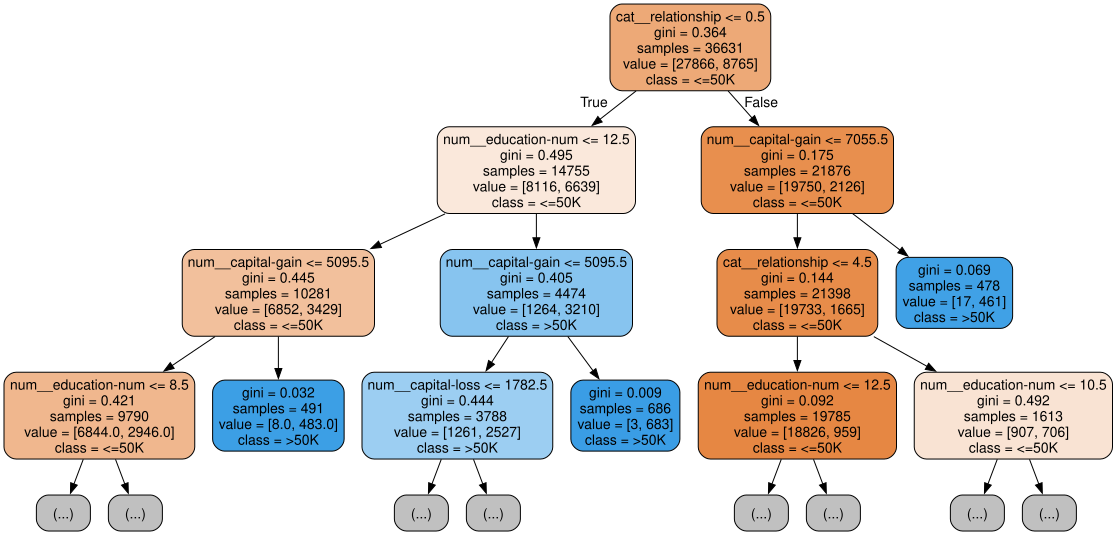

In [52]:
import graphviz
from IPython.display import HTML, display
from sklearn.tree import export_graphviz

clf = models["Best CCP Alpha"]
clf.fit(X_train, y_train)


gviz = export_graphviz(
    decision_tree=clf.named_steps["clf"],
    out_file=None,
    feature_names=feature_names,
    max_depth=3,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    special_characters=False,
)

graph = graphviz.Source(gviz)
style = "<style>svg{width:100% !important;height:auto !important;}</style>"
display(HTML(style))
display(graph)

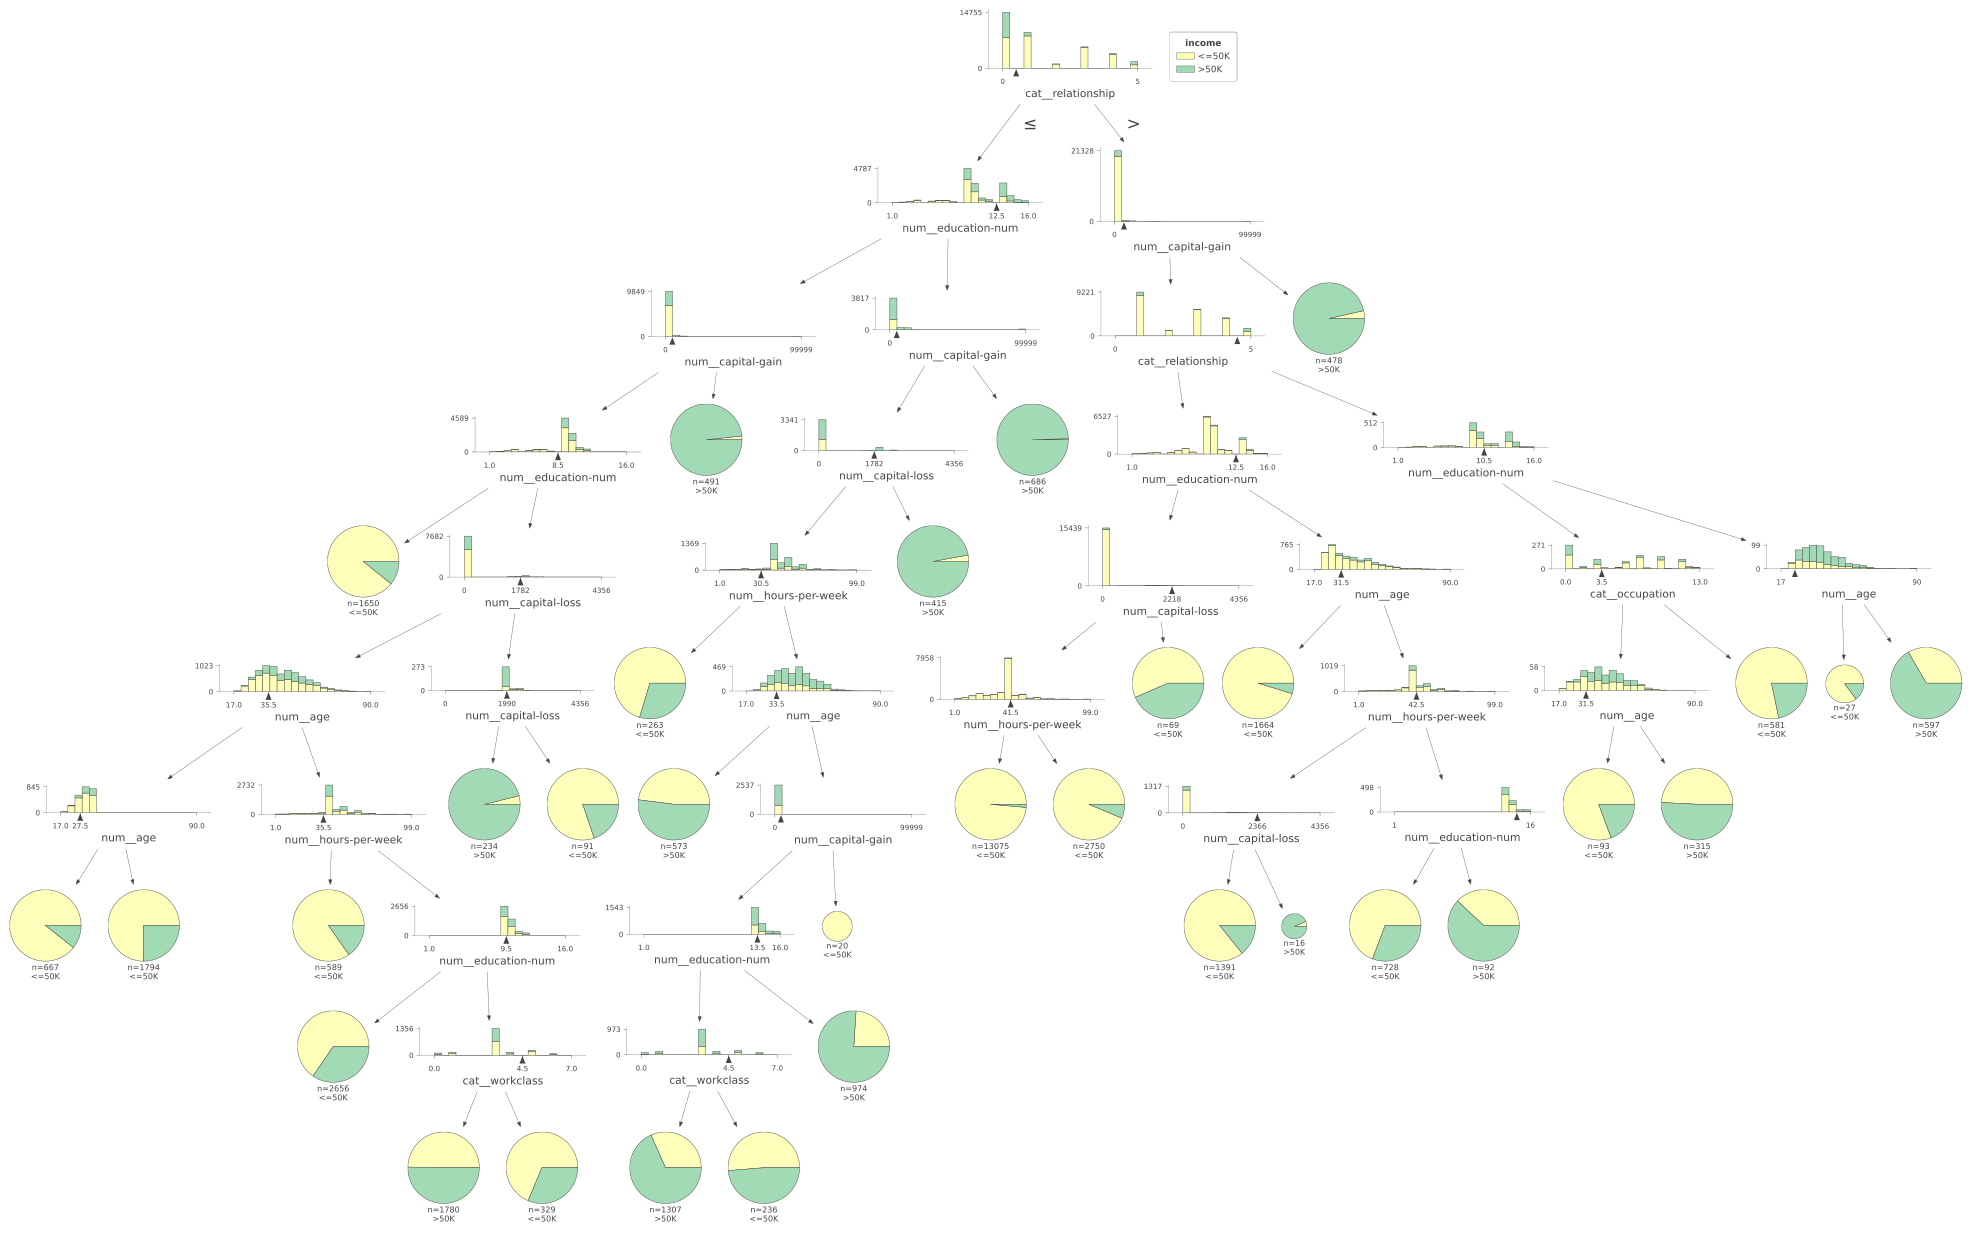

In [62]:
import dtreeviz

dtree_viz = dtreeviz.model(
    clf.named_steps["clf"],
    preprocessor.transform(X_train),
    y_train,
    target_name=target_col,
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
)

v = dtree_viz.view(fontname="DejaVu Sans", scale=1.2)
v

> Graphviz showcases if-else structure, applying saturations per confidence with gini=impurity.
>
> Dtreeviz shows distributions of features in nodes with threshold as black triangle and class distributions in leaves with pie charts.


### Task 9.

**Interpretability**. For the CCP-pruned tree, compute three types of feature importance:

- a) built-in ($\texttt{feature\_importances\_}$),
- b) $\texttt{permutation\_importance}$ on the test set,
- c) SHAP values ($\texttt{shap.TreeExplainer}$): $\texttt{shap.summary\_plot}$ for 1000 random records and $\texttt{shap.plots.waterfall}$ for one selected prediction.

_Comment: are the rankings from the three methods consistent? Where might the differences come from?_


In [ ]:
import shap
from sklearn.inspection import permutation_importance

ccp_pruned = models["Best CCP Alpha"]
ccp_pruned.fit(X_train, y_train)

built_in_importance = ccp_pruned.named_steps["clf"].feature_importances_

X_test_raw = preprocessor.transform(X_test)

perm_importance = permutation_importance(
    ccp_pruned.named_steps["clf"],
    X_test_raw,
    y_test,
    n_repeats=10,
    random_state=RNG,
    n_jobs=-1,
)

X_test_df = pd.DataFrame(X_test_raw, columns=feature_names)
X_test_sample = shap.sample(X_test_df, 1000)

explainer = shap.TreeExplainer(ccp_pruned.named_steps["clf"])
shap_values = explainer(X_test_sample)

shap_importance = np.abs(shap_values.values[:, :, 1]).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Built-in Importance": built_in_importance,
    "Permutation Importance": perm_importance.importances_mean,
    "SHAP Importance": shap_importance,
}).sort_values(by="SHAP Importance", ascending=False)
display(importance_df)

,Feature,Built-in Importance,Permutation Importance,SHAP Importance
0,num__age,0.036801,0.006838,0.032109
1,num__fnlwgt,0.000000,0.000000,0.000000
2,num__education-num,0.217322,0.058832,0.080063
3,num__capital-gain,0.217313,0.045492,0.048248
4,num__capital-loss,0.052605,0.005651,0.015342
5,num__hours-per-week,0.029387,0.008050,0.022558
6,cat__workclass,0.005839,0.002670,0.004669
7,cat__education,0.000000,0.000000,0.000000
8,cat__marital-status,0.000000,0.000000,0.000000
9,cat__occupation,0.003812,0.001695,0.003067


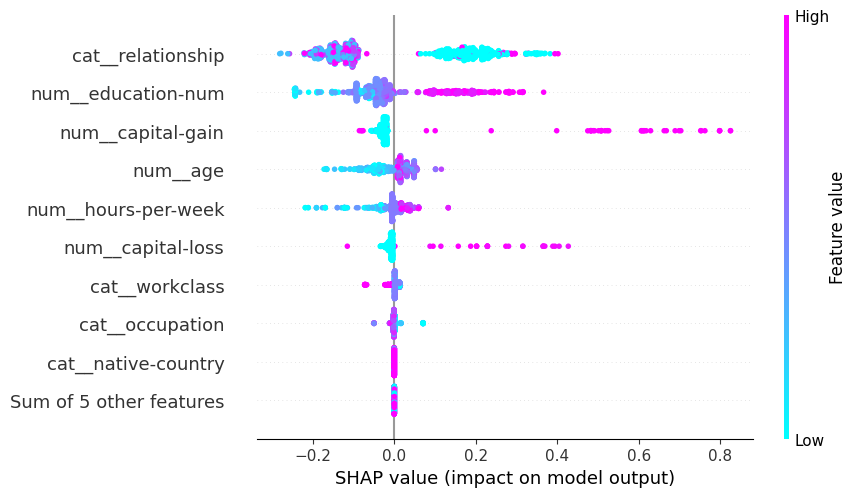

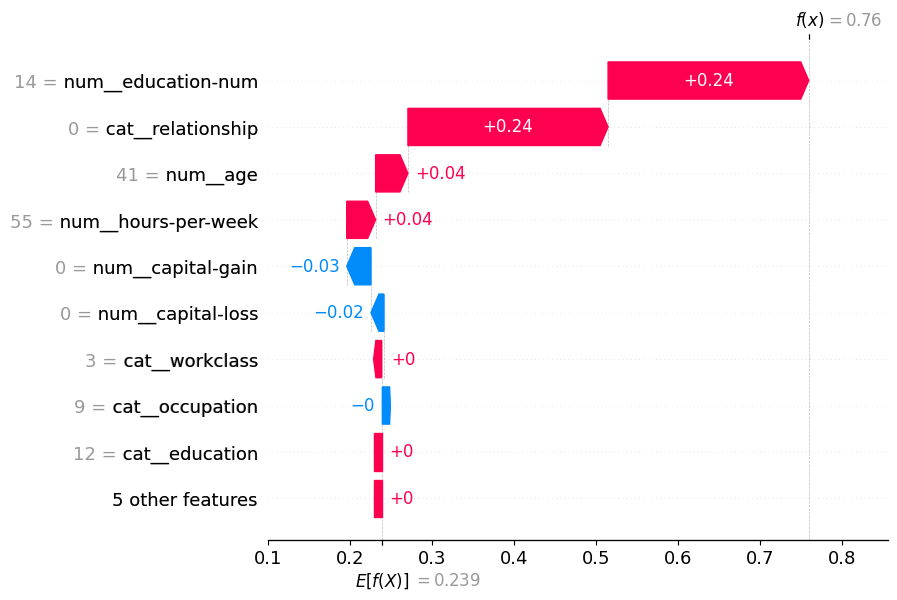

In [93]:
shap.plots.beeswarm(shap_values[:, :, 1], color=plt.get_cmap("cool"))  # Class 1 (>50K)
shap.plots.waterfall(shap_values[0, :, 1])

> The built-in, permuatation and SHAP seem to be consistent. The differences may come from the fact that built-in importance is based on the decrease in impurity, permutation importance is based on the decrease in accuracy when the feature column is permuted, and SHAP values are based on the contribution of each feature to the prediction for each record (game-theory). It's possible that CCP-pruned model is just ignoring the noise, so that's why they are consistent (?)


### Task 10.

_(optional)_ **Fairness audit**: does the model predict the positive class with different accuracy for subgroups defined by $\texttt{sex}$ and $\texttt{race}$? Compare _demographic parity_ and _equalized odds_ in both subgroups.


In [ ]:
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    equalized_odds_difference,
    selection_rate,
)
from sklearn.metrics import (
    accuracy_score,
    recall_score,
)

X_test_raw = preprocessor.transform(X_test)

discriminative_features = X_test[["sex", "race"]]

metrics = {
    "accuracy": accuracy_score,
    "tpr (recall)": recall_score,
    "selection_rate": selection_rate,
}

y_pred = ccp_pruned.named_steps["clf"].predict(X_test_raw)

mf = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=discriminative_features,
)

display(mf.by_group)

df = pd.DataFrame(
    {
        "sex_parity_difference": demographic_parity_difference(
            y_test, y_pred, sensitive_features=X_test["sex"]
        ),
        "sex_equalized_odds_difference": equalized_odds_difference(
            y_test, y_pred, sensitive_features=X_test["sex"]
        ),
        "race_parity_difference": demographic_parity_difference(
            y_test, y_pred, sensitive_features=X_test["race"]
        ),
        "race_equalized_odds_difference": equalized_odds_difference(
            y_test, y_pred, sensitive_features=X_test["race"]
        ),
    },
    index=[0],
)

display(df)

accuracy  tpr (recall)  selection_rate
sex    race                                                      
Female Amer-Indian-Eskimo  0.885714      0.333333        0.085714
       Asian-Pac-Islander  0.870504      0.588235        0.151079
       Black               0.946644      0.500000        0.053356
       Other               0.938776      0.750000        0.102041
       White               0.920186      0.615190        0.108075
Male   Amer-Indian-Eskimo  0.915663      0.600000        0.120482
       Asian-Pac-Islander  0.771654      0.682353        0.350394
       Black               0.889952      0.652542        0.167464
       Other               0.844828      0.428571        0.137931
       White               0.814236      0.645276        0.276762

,sex_parity_difference,sex_equalized_odds_difference,race_parity_difference,race_equalized_odds_difference
0,0.166716,0.067407,0.169729,0.121212


> The model is biased. It favours Asian-Pac-Islander males (35% selection rate to 77% accuracy). It also disfavours black females (5% selection rate to 94% accuracy).


## Random Forests


Before implementing, review the key theoretical concepts:

1. **Error decomposition**: $\mathbb{E}[(\hat{f}(x) - y)^2] = \text{bias}^2 + \text{variance} + \sigma^2_{\text{noise}}$. A deep tree has low bias and high variance.
2. **Bagging** (Breiman 1996): $B$ independent bootstrap samples generate $B$ trees. The variance of their mean is $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$, where $\rho$ is the average pairwise correlation between trees.
3. **Random Forest** (Breiman 2001): additional randomization via $\texttt{max\_features}$ reduces $\rho$, significantly improving the effectiveness of bagging.
4. **Out-of-bag**: each tree is trained on ${\approx}63\%$ of unique samples; the remaining ${\approx}37\%$ (OOB) serve as a free generalization estimator.


### Task 1.

Examine the convergence of the random forest as $\texttt{n\_estimators}$ grows. Use $\texttt{warm\_start=True}$: for $n \in \{10, 20, 50, 100, 200, 300, 500\}$, incrementally fit the model and record OOB score and test accuracy. Plot the convergence curve.


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier

n_estimators = [10, 20, 50, 100, 200, 300, 500]


def evaluate_rf_estimators(n):
    rf_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=n, random_state=RNG, warm_start=True, oob_score=True
            ),
        ),
    ])
    rf_pipeline.fit(X_train, y_train)
    return {
        "n_estimators": n,
        "test_acc": rf_pipeline.score(X_test, y_test),
        "oob_score": rf_pipeline.named_steps["clf"].oob_score_,
    }


rf_results = Parallel(n_jobs=-1)(
    delayed(evaluate_rf_estimators)(n) for n in tqdm(n_estimators)
)


100%|██████████| 7/7 [00:00<00:00, 18430.71it/s]
/home/aligator/projects/agh/de/.venv/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/aligator/projects/agh/de/.venv/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


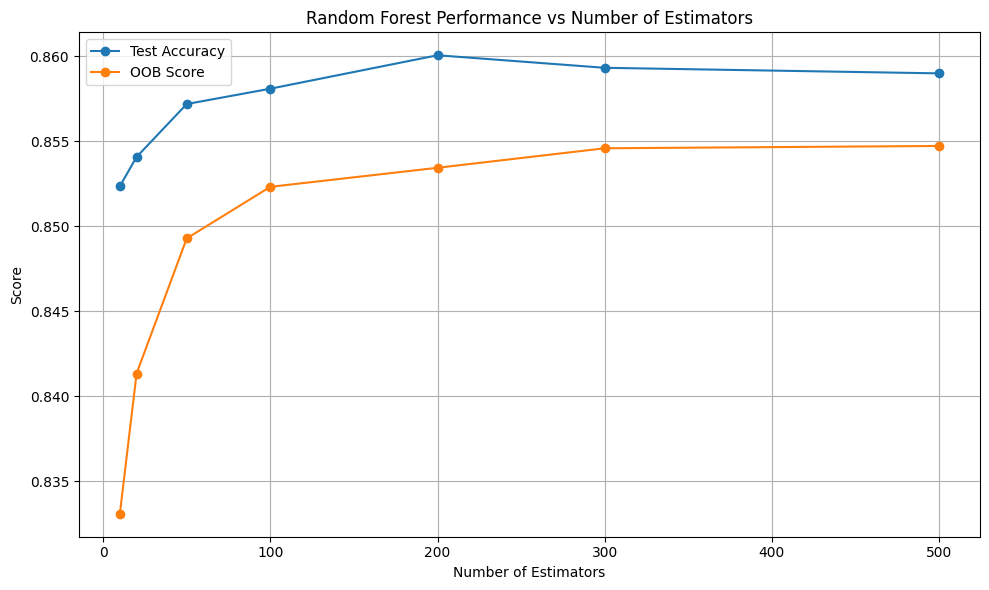

In [123]:
plt.figure(figsize=(10, 6))
plt.plot(
    [r["n_estimators"] for r in rf_results],
    [r["test_acc"] for r in rf_results],
    marker="o",
    label="Test Accuracy",
)
plt.plot(
    [r["n_estimators"] for r in rf_results],
    [r["oob_score"] for r in rf_results],
    marker="o",
    label="OOB Score",
)
plt.xlabel("Number of Estimators")
plt.ylabel("Score")
plt.title("Random Forest Performance vs Number of Estimators")
plt.legend(["Test Accuracy", "OOB Score"])
plt.grid()
plt.tight_layout()
plt.show()

### Task 2.

Examine the effect of $\texttt{max\_features} \in \{1,\ 2,\ 4,\ \texttt{'sqrt'},\ \texttt{'log2'},\ 0.5,\ \texttt{None}\}$ at $\texttt{n\_estimators}=200$. Build a table of OOB score vs test accuracy. _Comment: which value gives the best compromise? Why do extreme values hurt?_


In [ ]:
max_features = [1, 2, 4, "sqrt", "log2", 0.5, None]


def evaluate_rf_max_features(m):
    rf_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200,
                random_state=RNG,
                max_features=m,
                oob_score=True,
                warm_start=True,
            ),
        ),
    ])
    rf_pipeline.fit(X_train, y_train)
    return {
        "max_features": m,
        "test_acc": rf_pipeline.score(X_test, y_test),
        "oob_score": rf_pipeline.named_steps["clf"].oob_score_,
    }


rf_max_features_results = Parallel(n_jobs=-1)(
    delayed(evaluate_rf_max_features)(m) for m in tqdm(max_features)
)

df = pd.DataFrame(rf_max_features_results)
display(df)

100%|██████████| 7/7 [00:00<00:00, 14448.88it/s]


,max_features,test_acc,oob_score
0,1,0.857506,0.852584
1,2,0.860044,0.854276
2,4,0.859799,0.854195
3,sqrt,0.860044,0.853430
4,log2,0.860044,0.853430
5,0.5,0.859062,0.853785
6,None,0.856850,0.851219


> The best is either 2 or `sqrt`.
> Extreme values hurt becauase if too low, the trees may be too weak (forced to split on possibly irrelevant features), if too high, the trees may end up choosing the same strong features, increasing correlation and variance.


### Task 3

_(optional)_ **Bayesian optimization**. Using the $\texttt{Optuna}$ library, optimize the RF hyperparameters over the following search space:


In [132]:
import optuna


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.3, 0.5, 0.8]
        ),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
    }

    rf_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(**params, random_state=RNG, n_jobs=-1)),
    ])

    return cross_val_score(
        rf_pipeline, X_train, y_train, cv=5, scoring="balanced_accuracy"
    ).mean()


study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=RNG)
)

study.optimize(objective, n_trials=25)

[I 2026-04-29 02:16:39,956] A new study created in memory with name: no-name-c46b6e17-7c0f-4fed-8332-a7f48400f0cb
[I 2026-04-29 02:16:57,658] Trial 14 finished with value: 0.763446387059082 and parameters: {'n_estimators': 300, 'max_depth': 14, 'max_features': 'log2', 'min_samples_leaf': 13, 'min_samples_split': 18}. Best is trial 3 with value: 0.7733718840721275.
[I 2026-04-29 02:16:58,426] Trial 9 finished with value: 0.7504877096179476 and parameters: {'n_estimators': 300, 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 11, 'min_samples_split': 21}. Best is trial 3 with value: 0.7733718840721275.
[I 2026-04-29 02:16:58,464] Trial 7 finished with value: 0.7708703940738741 and parameters: {'n_estimators': 300, 'max_depth': 29, 'max_features': 'log2', 'min_samples_leaf': 10, 'min_samples_split': 15}. Best is trial 3 with value: 0.7733718840721275.
[I 2026-04-29 02:16:59,832] Trial 1 finished with value: 0.7700873786193083 and parameters: {'n_estimators': 300, 'max_depth': 

In [143]:
print(f"Best parameters: {study.best_params}")
print(f"Best value: {study.best_value}")

Best parameters: {'n_estimators': 100, 'max_depth': 26, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 23}
Best value: 0.7782769188804808


### Task 4.

Compare the best Random Forest with $\texttt{HistGradientBoostingClassifier}$ (default parameters, $\texttt{max\_iter}=300$). Build a comparison table: Decision Tree (CCP) / Random Forest (Optuna) / HistGradientBoosting. _Comment: which model wins and what price do you pay for the quality improvement?_


In [140]:
import time

from sklearn.ensemble import HistGradientBoostingClassifier

models = {
    "optuna_best": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(**study.best_params, random_state=RNG)),
    ]),
    "hist_gradient_boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", HistGradientBoostingClassifier(max_iter=300, random_state=RNG)),
    ]),
    "best_cpp_alpha": Pipeline([
        ("preprocessor", preprocessor),
        (
            "clf",
            DecisionTreeClassifier(random_state=RNG, ccp_alpha=alpha_star),
        ),
    ]),
}


def evaluate_model(name, pipeline):
    start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    end = time.perf_counter()
    return {
        "model": name,
        "train_acc": pipeline.score(X_train, y_train),
        "test_acc": pipeline.score(X_test, y_test),
        "f1_score": f1_score(y_test, pipeline.predict(X_test)),
        "overfit_gap": pipeline.score(X_train, y_train)
        - pipeline.score(X_test, y_test),
        "train_time": end - start,
    }


results = Parallel(n_jobs=-1)(
    delayed(evaluate_model)(name, model) for name, model in models.items()
)

df = pd.DataFrame(results)
display(df)

,model,train_acc,test_acc,f1_score,overfit_gap,train_time
0,optuna_best,0.909667,0.867415,0.690617,0.042252,2.210167
1,hist_gradient_boosting,0.885834,0.876669,0.717342,0.009166,0.474675
2,best_cpp_alpha,0.855287,0.853657,0.676561,0.001630,0.196012


> The best is HistGradientBoosting with 87,6% test acc and 71 f1-score. It has a slightly higher training time that cpp-optimized DT, but far better than optuna-optimized RF. The price is the loss of interpretability, HGBoosting uses gradient to improve the model, there is no easy pinpoint of the decison process.


### Task 5.

_(optional)_ Repeat the interpretability analysis from the Decision Trees section (built-in importance, $\texttt{permutation\_importance}$, SHAP) for the Random Forest. How do the feature rankings change compared to a single tree?


In [146]:
optuna_best = models["optuna_best"]
optuna_best.fit(X_train, y_train)

built_in_importance = optuna_best.named_steps["clf"].feature_importances_

X_test_raw = preprocessor.transform(X_test)

perm_importance = permutation_importance(
    optuna_best.named_steps["clf"],
    X_test_raw,
    y_test,
    n_repeats=10,
    random_state=RNG,
    n_jobs=-1,
)

X_test_df = pd.DataFrame(X_test_raw, columns=feature_names)
X_test_sample = shap.sample(X_test_df, 1000)

explainer = shap.TreeExplainer(optuna_best.named_steps["clf"])
shap_values = explainer(X_test_sample)

shap_importance = np.abs(shap_values.values[:, :, 1]).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Built-in Importance": built_in_importance,
    "Permutation Importance": perm_importance.importances_mean,
    "SHAP Importance": shap_importance,
}).sort_values(by="SHAP Importance", ascending=False)
display(importance_df)

,Feature,Built-in Importance,Permutation Importance,SHAP Importance
10,cat__relationship,0.158574,0.026493,0.079809
2,num__education-num,0.126962,0.031963,0.065225
8,cat__marital-status,0.105749,0.009090,0.060624
3,num__capital-gain,0.177980,0.047613,0.048351
0,num__age,0.101795,0.017935,0.044720
5,num__hours-per-week,0.066253,0.008910,0.033870
4,num__capital-loss,0.051971,0.011252,0.016915
9,cat__occupation,0.041998,0.009287,0.016578
7,cat__education,0.032679,0.001147,0.014372
12,cat__sex,0.013040,0.001998,0.011442


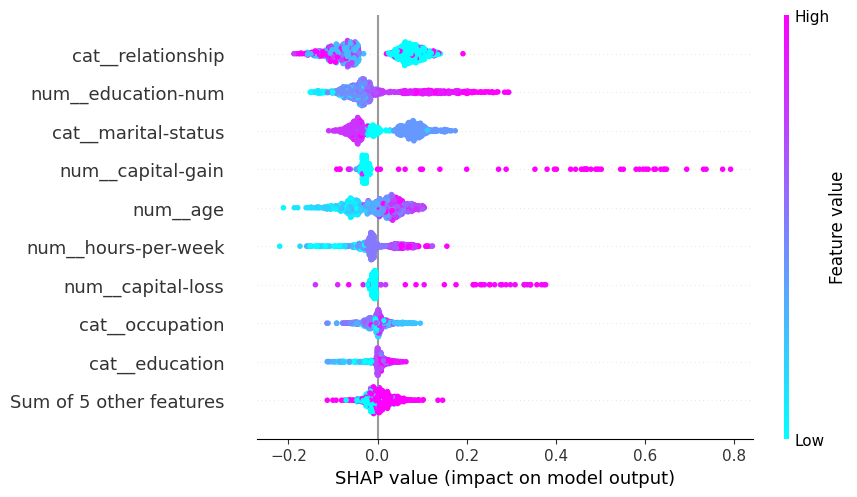

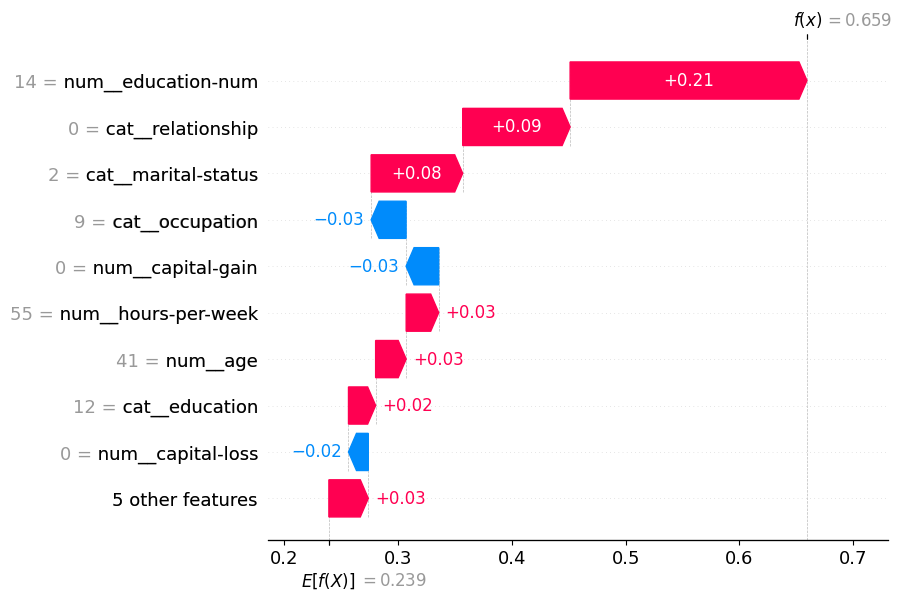

In [145]:
shap.plots.beeswarm(shap_values[:, :, 1], color=plt.get_cmap("cool"))  # Class 1 (>50K)
shap.plots.waterfall(shap_values[0, :, 1])

> The rankings are far more dense. It's possible that DT pruned out the noise, so the ranking there is sparse. With RF each tree may be capturing different aspects of the data (is more vocal), so the importance is more distributed across features. Also, the different feature importance methods pointed to different features: built-in to `capital-gain`, permutation to `hours-per-week`, SHAP to `relationship` (actually the same).


## $k$-NN classifier


### Task 1

Load the _Palmer Penguins_ dataset ($\texttt{fetch\_openml('penguins',\ version=1)}$). Remove NaN rows, encode categorical features and the target label, and **apply $\texttt{StandardScaler}$**. _Justify_ why scaling is necessary for $k$-NN.


In [291]:
penguins = fetch_openml(name="penguins", version=1, as_frame=True, parser="auto")
penguins_raw_df = penguins.frame
penguins_df = penguins_raw_df.copy()
penguins_df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


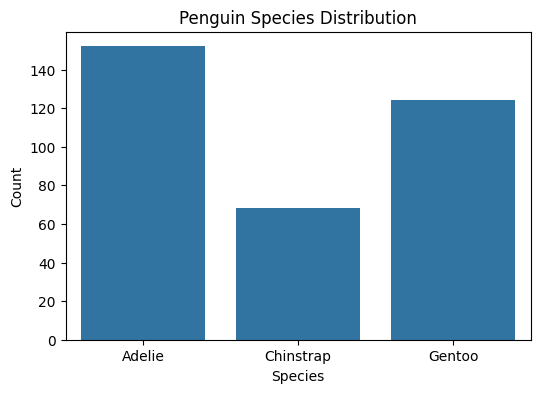

In [292]:
species_counts = penguins_raw_df["species"].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=species_counts.index, y=species_counts.values)
plt.title("Penguin Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

In [293]:
print(
    f"Dataset loaded: {penguins_df.shape[0]} samples, {penguins_df.shape[1]} features"
)
print(f"Missing values:\n{penguins_df.isna().sum()}")
print(f"Duplicates: {penguins_df.duplicated().sum()}")

Dataset loaded: 344 samples, 7 features
Missing values:
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64
Duplicates: 0


In [294]:
penguins_df.dropna(inplace=True)
print(f"Missing values:\n{penguins_df.isna().sum()}")

Missing values:
species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [295]:
y = penguins_df.pop("species")

In [296]:
categorical_features = penguins_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = penguins_df.select_dtypes(include=["number"]).columns.tolist()

print(f"({len(categorical_features)}) Categorical columns: {categorical_features}")
print(f"({len(numerical_features)}) Numerical columns: {numerical_features}")

(2) Categorical columns: ['island', 'sex']
(4) Numerical columns: ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']


In [297]:
from sklearn.calibration import LabelEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

numerical_transformer = Pipeline([
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features),
])

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    penguins_df, y, test_size=0.3, stratify=y, random_state=RNG
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [298]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((233, 9), (101, 9), (233,), (101,))

> Scaling for $k$-NN is necessary because it is a distance-based algorithm, so a very large feature can domintate the metric if not scaled.


### Task 2

Test all combinations of $k \in \{1, 3, 5, 7, 9, 11, 15\}$, $\texttt{metric} \in \{\texttt{euclidean},\ \texttt{manhattan},\ \texttt{chebyshev}\}$, $\texttt{weights} \in \{\texttt{uniform},\ \texttt{distance}\}$. For each combination compute 5-fold CV accuracy. Visualize the results as a heatmap.


In [309]:
from sklearn.neighbors import KNeighborsClassifier

parameters = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 15],
    "metric": ["euclidean", "manhattan", "chebyshev"],
    "weights": ["uniform", "distance"],
}

clf = KNeighborsClassifier()

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

knn_cv = GridSearchCV(
    clf,
    param_grid=parameters,
    cv=kf,
    scoring="balanced_accuracy",
    n_jobs=-1,
    return_train_score=True,
)

knn_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [1, 3, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

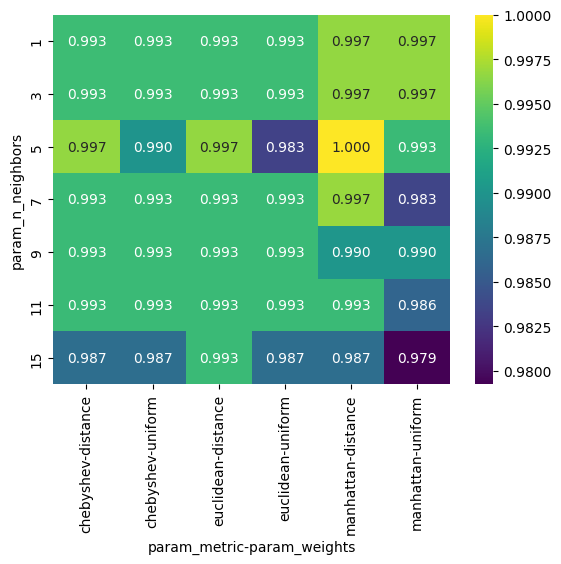

In [310]:
sns.heatmap(
    pd.DataFrame(GCV.cv_results_).pivot_table(
        index="param_n_neighbors",
        columns=["param_metric", "param_weights"],
        values="mean_test_score",
    ),
    annot=True,
    fmt=".3f",
    cmap="viridis",
)
plt.show()

In [312]:
print(f"Best parameters: {knn_cv.best_params_}")

Best parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}


3. Repeat the analysis for the NYT-frame dataset (reduced by PCA to 10 dimensions). Observe how the choice of metric depends on dimensionality.


In [318]:
nyt_df = pd.read_csv("data/nyt-frame.csv")

4. _(optional)_ **Own KD-tree implementation**. Test on 10,000 random 10D points by comparing nearest-neighbor search time: brute-force (NumPy) vs $\texttt{sklearn.neighbors.KDTree}$ vs $\texttt{scipy.spatial.cKDTree}$.


5. _(optional)_ Perform Bayesian hyperparameter optimization for $k$-NN ($\texttt{scikit\text{-}optimize}$ or $\texttt{Optuna}$) over the following parameter space: $\texttt{n\_neighbors} \in (1, 20)$, $\texttt{metric} \in \{\texttt{'euclidean'},\ \texttt{'manhattan'},\ \texttt{'cosine'}\}$, $\texttt{weights} \in \{\texttt{'uniform'},\ \texttt{'distance'}\}$.


## Summary questions

1. Which tree regularization strategy (pre-pruning, post-pruning, hybrid) proved most effective and why?


2. Are the feature rankings according to built-in importance, $\texttt{permutation\_importance}$, and SHAP consistent? How should discrepancies be interpreted?


3. What is the gain of Random Forest compared to a single tree, and of gradient boosting compared to RF? What is the cost of this gain?


4. How does the bias-variance trade-off behave in Random Forest as a function of $\texttt{max\_features}$?


5. What fairness risks are associated with using a model trained on the Adult Census dataset?
